In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_validate

In [2]:
from google.colab import files

uploaded = files.upload()

Saving stock_price_prediction_dataset.csv to stock_price_prediction_dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("stock_price_prediction_dataset.csv")

df.head()

,Date,Open,High,Low,Close,Volume,MA_5,MA_20,Daily_Return,Target_Next_Close
0,2023-01-01,149.93,151.39,148.97,150.70,1866359,149.18,149.07,-0.0042,150.07
1,2023-01-02,150.41,150.75,149.75,150.07,1584410,149.18,149.07,-0.0042,148.73
2,2023-01-03,150.23,150.46,148.66,148.73,2690911,149.18,149.07,-0.0089,148.47
3,2023-01-04,148.79,149.14,148.15,148.47,2418275,149.18,149.07,-0.0017,147.95
4,2023-01-05,147.95,148.69,147.81,147.95,2062844,149.18,149.07,-0.0035,144.52


In [4]:
df.shape

(1000, 10)

In [5]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA_5', 'MA_20',
       'Daily_Return', 'Target_Next_Close'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1000 non-null   object 
 1   Open               1000 non-null   float64
 2   High               1000 non-null   float64
 3   Low                1000 non-null   float64
 4   Close              1000 non-null   float64
 5   Volume             1000 non-null   int64  
 6   MA_5               1000 non-null   float64
 7   MA_20              1000 non-null   float64
 8   Daily_Return       1000 non-null   float64
 9   Target_Next_Close  1000 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 78.3+ KB


In [7]:
df.describe()

,Open,High,Low,Close,Volume,MA_5,MA_20,Daily_Return,Target_Next_Close
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.00000,1000.00000,1000.000000,1000.000000
mean,176.657590,177.763010,175.594110,176.694880,2.004743e+06,176.62509,176.39515,0.000232,176.727630
std,12.063792,12.040815,12.034104,12.033683,4.485153e+05,12.01841,11.98852,0.008736,12.007403
min,144.080000,145.130000,143.630000,144.520000,8.829020e+05,145.74000,149.04000,-0.025200,144.520000
25%,165.655000,166.877500,164.732500,165.850000,1.696600e+06,165.46500,164.95750,-0.005700,166.022500
50%,179.640000,180.715000,178.575000,179.700000,1.969989e+06,179.68000,179.90500,0.000100,179.700000
75%,185.140000,186.120000,183.892500,185.152500,2.295474e+06,184.72000,184.65750,0.006200,185.152500
max,201.070000,201.940000,198.880000,200.150000,3.391571e+06,199.25000,197.18000,0.030900,200.150000


In [8]:
df.head(10)

,Date,Open,High,Low,Close,Volume,MA_5,MA_20,Daily_Return,Target_Next_Close
0,2023-01-01,149.93,151.39,148.97,150.70,1866359,149.18,149.07,-0.0042,150.07
1,2023-01-02,150.41,150.75,149.75,150.07,1584410,149.18,149.07,-0.0042,148.73
2,2023-01-03,150.23,150.46,148.66,148.73,2690911,149.18,149.07,-0.0089,148.47
3,2023-01-04,148.79,149.14,148.15,148.47,2418275,149.18,149.07,-0.0017,147.95
4,2023-01-05,147.95,148.69,147.81,147.95,2062844,149.18,149.07,-0.0035,144.52
5,2023-01-06,147.44,147.47,143.79,144.52,1736662,147.95,149.07,-0.0232,144.84
6,2023-01-07,144.33,145.13,143.65,144.84,2457384,146.90,149.07,0.0022,145.50
7,2023-01-08,144.08,146.33,143.63,145.50,1791132,146.26,149.07,0.0046,145.91
8,2023-01-09,146.00,146.61,145.61,145.91,2131282,145.74,149.07,0.0028,148.04
9,2023-01-10,145.71,148.52,145.64,148.04,2468619,145.76,149.07,0.0146,150.02


In [9]:
df.tail(10)

,Date,Open,High,Low,Close,Volume,MA_5,MA_20,Daily_Return,Target_Next_Close
990,2025-09-17,177.57,179.16,177.45,179.11,2580881,178.06,178.09,0.0075,179.41
991,2025-09-18,178.47,179.52,178.35,179.41,1800341,178.36,178.31,0.0017,180.33
992,2025-09-19,179.39,181.07,178.49,180.33,2474244,178.89,178.60,0.0051,181.64
993,2025-09-20,180.92,182.24,180.36,181.64,1766113,179.65,178.87,0.0073,183.08
994,2025-09-21,181.78,183.97,181.28,183.08,1603465,180.71,179.21,0.0079,183.40
995,2025-09-22,183.71,183.92,183.12,183.40,1594109,181.57,179.51,0.0017,182.27
996,2025-09-23,182.79,183.65,181.95,182.27,1523017,182.14,179.75,-0.0062,182.32
997,2025-09-24,182.25,182.53,182.12,182.32,1655980,182.54,179.96,0.0003,184.46
998,2025-09-25,182.65,184.95,181.74,184.46,2274170,183.11,180.30,0.0117,183.45
999,2025-09-26,184.67,185.41,182.92,183.45,2069543,183.18,180.48,-0.0055,183.45


In [10]:
df.tail(10)

,Date,Open,High,Low,Close,Volume,MA_5,MA_20,Daily_Return,Target_Next_Close
990,2025-09-17,177.57,179.16,177.45,179.11,2580881,178.06,178.09,0.0075,179.41
991,2025-09-18,178.47,179.52,178.35,179.41,1800341,178.36,178.31,0.0017,180.33
992,2025-09-19,179.39,181.07,178.49,180.33,2474244,178.89,178.60,0.0051,181.64
993,2025-09-20,180.92,182.24,180.36,181.64,1766113,179.65,178.87,0.0073,183.08
994,2025-09-21,181.78,183.97,181.28,183.08,1603465,180.71,179.21,0.0079,183.40
995,2025-09-22,183.71,183.92,183.12,183.40,1594109,181.57,179.51,0.0017,182.27
996,2025-09-23,182.79,183.65,181.95,182.27,1523017,182.14,179.75,-0.0062,182.32
997,2025-09-24,182.25,182.53,182.12,182.32,1655980,182.54,179.96,0.0003,184.46
998,2025-09-25,182.65,184.95,181.74,184.46,2274170,183.11,180.30,0.0117,183.45
999,2025-09-26,184.67,185.41,182.92,183.45,2069543,183.18,180.48,-0.0055,183.45


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df = df.sort_values('Date')

In [13]:
df.head()

,Date,Open,High,Low,Close,Volume,MA_5,MA_20,Daily_Return,Target_Next_Close
0,2023-01-01,149.93,151.39,148.97,150.70,1866359,149.18,149.07,-0.0042,150.07
1,2023-01-02,150.41,150.75,149.75,150.07,1584410,149.18,149.07,-0.0042,148.73
2,2023-01-03,150.23,150.46,148.66,148.73,2690911,149.18,149.07,-0.0089,148.47
3,2023-01-04,148.79,149.14,148.15,148.47,2418275,149.18,149.07,-0.0017,147.95
4,2023-01-05,147.95,148.69,147.81,147.95,2062844,149.18,149.07,-0.0035,144.52


In [14]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
MA_5,0
MA_20,0
Daily_Return,0
Target_Next_Close,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()

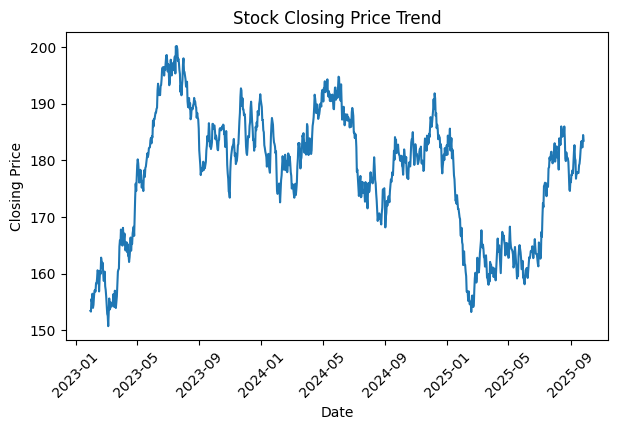

In [99]:
plt.figure(figsize=(7,4))

plt.plot(df['Date'], df['Close'])

plt.title('Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.xticks(rotation=45)
plt.show()

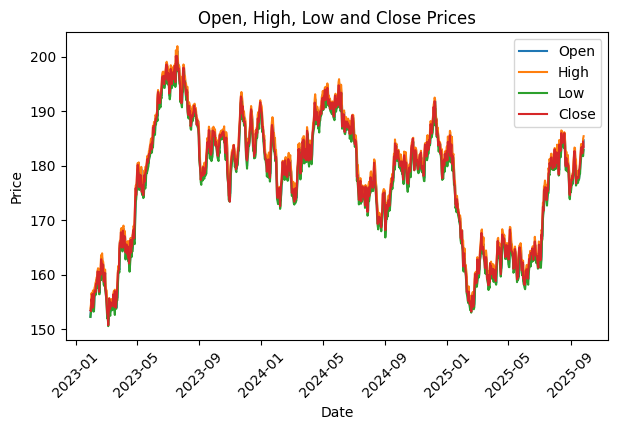

In [98]:
plt.figure(figsize=(7,4))

plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.plot(df['Date'], df['Close'], label='Close')

plt.title('Open, High, Low and Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.xticks(rotation=45)
plt.show()

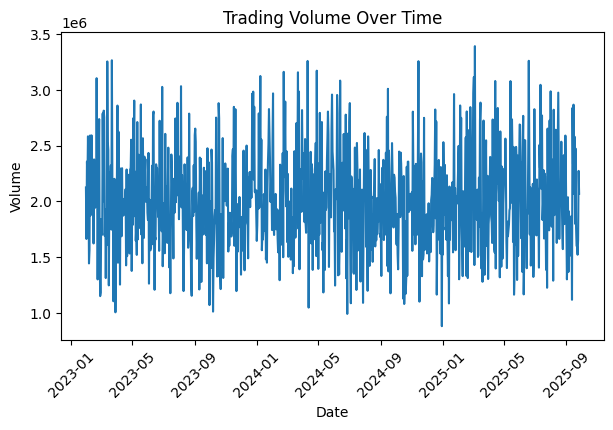

In [97]:
plt.figure(figsize=(7,4))

plt.plot(df['Date'], df['Volume'])

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.xticks(rotation=45)
plt.show()

In [26]:
df['MA_7'] = df['Close'].rolling(window=7).mean()

In [27]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

In [33]:
df['Daily_Return'] = df['Close'].pct_change()

In [34]:
df['Daily_Return'] = df['Close'].pct_change() * 100

In [35]:
df['Volatility_7'] = df['Daily_Return'].rolling(window=7).std()

In [36]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
MA_5,0
MA_20,0
Daily_Return,1
Target_Next_Close,0


In [37]:
df = df.dropna()

In [38]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
MA_5,0
MA_20,0
Daily_Return,0
Target_Next_Close,0


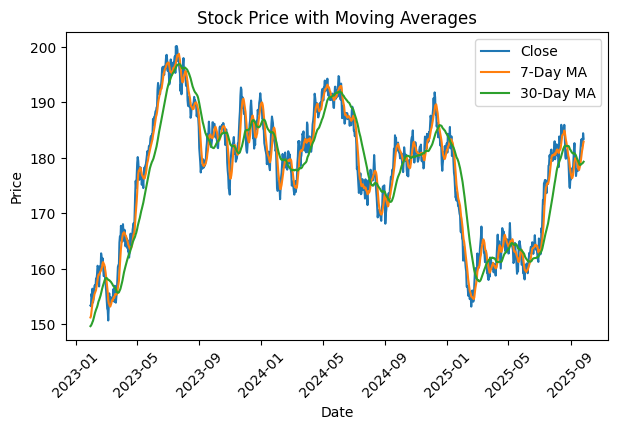

In [96]:
plt.figure(figsize=(7,4))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_7'], label='7-Day MA')
plt.plot(df['Date'], df['MA_30'], label='30-Day MA')

plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.xticks(rotation=45)

plt.show()

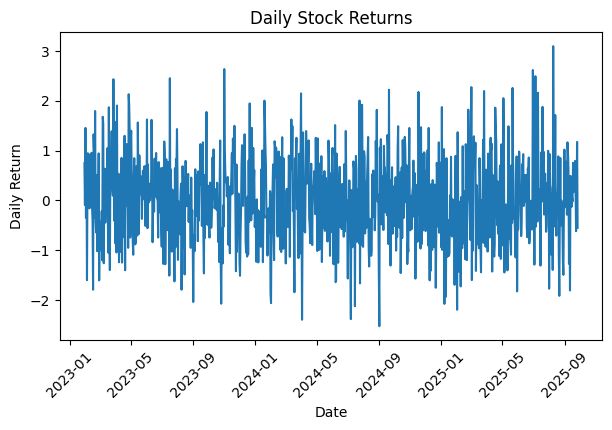

In [95]:
plt.figure(figsize=(7,4))

plt.plot(df['Date'], df['Daily_Return'])

plt.title('Daily Stock Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')

plt.xticks(rotation=45)
plt.show()

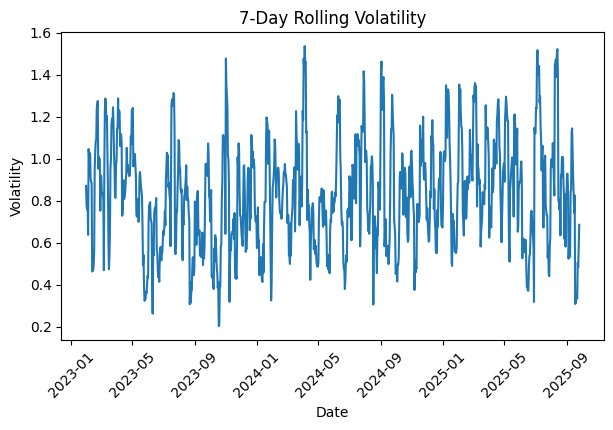

In [94]:
plt.figure(figsize=(7,4))

plt.plot(df['Date'], df['Volatility_7'])

plt.title('7-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.xticks(rotation=45)
plt.show()

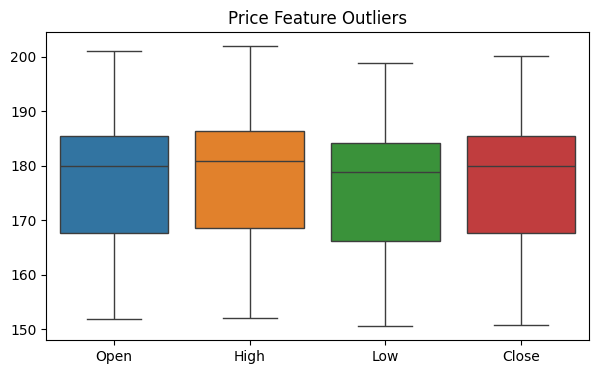

In [93]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df[['Open','High','Low','Close']])

plt.title('Price Feature Outliers')
plt.show()

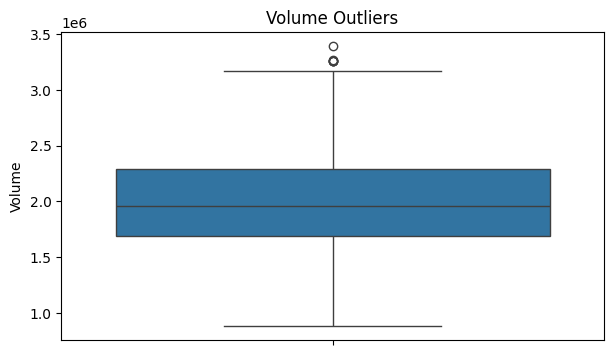

In [92]:
plt.figure(figsize=(7,4))

sns.boxplot(y=df['Volume'])

plt.title('Volume Outliers')
plt.show()

In [46]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Volume'] < lower) |
    (df['Volume'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 6


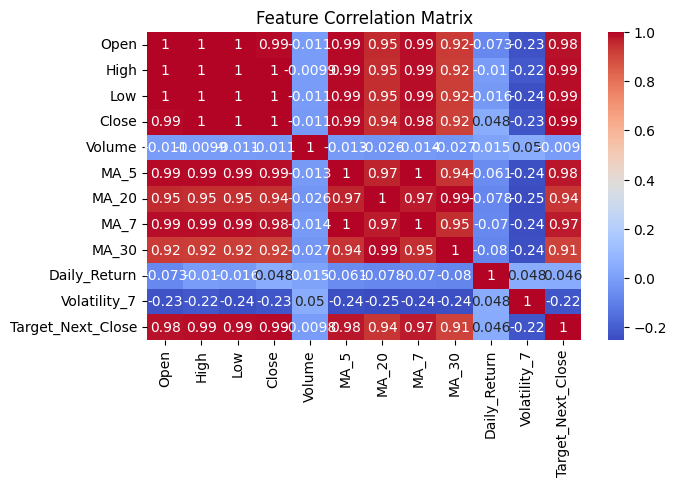

In [91]:
plt.figure(figsize=(7,4))

corr = df[
    ['Open','High','Low','Close','Volume',
     'MA_5','MA_20','MA_7','MA_30',
     'Daily_Return','Volatility_7',
     'Target_Next_Close']
].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Feature Correlation Matrix')

plt.show()

In [49]:
X = df[
    ['Open',
     'High',
     'Low',
     'Close',
     'Volume',
     'MA_5',
     'MA_20',
     'MA_7',
     'MA_30',
     'Daily_Return',
     'Volatility_7']
]

In [50]:
y = df['Target_Next_Close']

In [52]:
split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [54]:
scaler.fit(X_train)

StandardScaler()

In [55]:
scaler.transform(X_train)
scaler.transform(X_test)

array([[-1.55191906e+00, -1.62187963e+00, -1.60703815e+00, ...,
        -1.75358183e+00, -1.12391365e+00, -9.58118063e-01],
       [-1.68224244e+00, -1.59350674e+00, -1.65816160e+00, ...,
        -1.72976200e+00,  9.69641368e-01, -6.87922625e-01],
       [-1.47172006e+00, -1.47269312e+00, -1.41532521e+00, ...,
        -1.70465296e+00,  4.27248498e-01, -5.58308106e-01],
       ...,
       [ 2.58937975e-01,  1.83917831e-01,  3.46607952e-01, ...,
        -1.32920464e-02,  1.74878006e-02, -1.35101811e+00],
       [ 2.95392067e-01,  4.05409461e-01,  3.11917040e-01, ...,
        -6.14743647e-04,  1.34486162e+00, -9.21974687e-01],
       [ 4.79485233e-01,  4.47511176e-01,  4.19641451e-01, ...,
         1.08961245e-02, -6.48296961e-01, -5.44851458e-01]])

In [56]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

In [57]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

In [58]:
linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

In [59]:
linear_r2 = r2_score(
    y_test,
    linear_predictions
)

In [60]:
print("Linear Regression")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("R2:", linear_r2)

Linear Regression
MAE: 1.20467654150101
MSE: 2.337560890956089
R2: 0.9705285717505091


In [61]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [62]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [63]:
poly_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [64]:
poly_predictions = poly_model.predict(X_test)

In [65]:
poly_mae = mean_absolute_error(
    y_test,
    poly_predictions
)

poly_mse = mean_squared_error(
    y_test,
    poly_predictions
)

poly_r2 = r2_score(
    y_test,
    poly_predictions
)

print("Polynomial Regression")
print("MAE:", poly_mae)
print("MSE:", poly_mse)
print("R2:", poly_r2)

Polynomial Regression
MAE: 1.2717036964180983
MSE: 2.524380406564701
R2: 0.968173194412034


In [66]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [67]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_mse = mean_squared_error(
    y_test,
    tree_predictions
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree")
print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("R2:", tree_r2)

Decision Tree
MAE: 1.4787604810381318
MSE: 3.686174326885891
R2: 0.9535255647841117


In [68]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Decision Tree'
    ],

    'MAE': [
        linear_mae,
        poly_mae,
        tree_mae
    ],

    'MSE': [
        linear_mse,
        poly_mse,
        tree_mse
    ],

    'R2 Score': [
        linear_r2,
        poly_r2,
        tree_r2
    ]
})

results

,Model,MAE,MSE,R2 Score
0,Linear Regression,1.204677,2.337561,0.970529
1,Polynomial Regression,1.271704,2.524380,0.968173
2,Decision Tree,1.478760,3.686174,0.953526


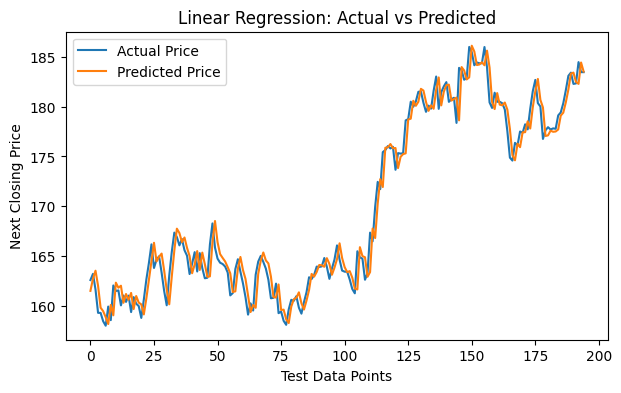

In [90]:
plt.figure(figsize=(7,4))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    linear_predictions,
    label='Predicted Price'
)

plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Next Closing Price')

plt.legend()
plt.show()

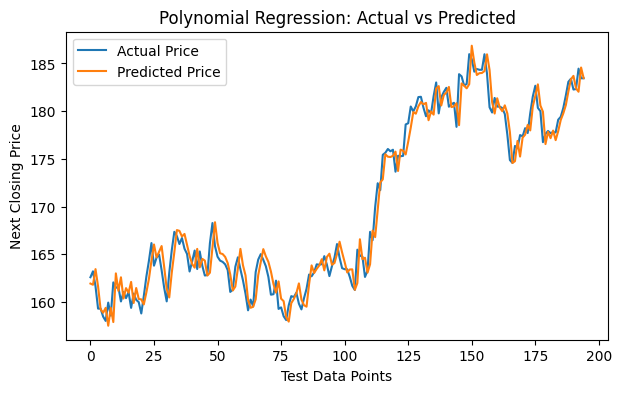

In [89]:
plt.figure(figsize=(7,4))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    poly_predictions,
    label='Predicted Price'
)

plt.title('Polynomial Regression: Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Next Closing Price')

plt.legend()
plt.show()

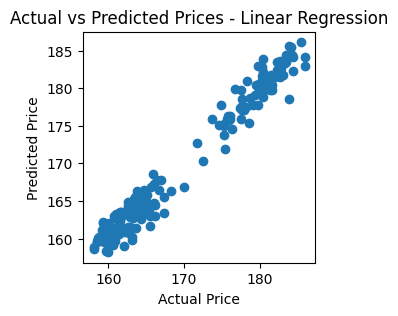

In [74]:
plt.figure(figsize=(3,3))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Prices - Linear Regression')

plt.show()

In [75]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [76]:
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [77]:
cv_results = cross_validate(
    linear_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
)

In [78]:
print(
    "Average MAE:",
    -cv_results['test_MAE'].mean()
)

print(
    "Average MSE:",
    -cv_results['test_MSE'].mean()
)

print(
    "Average R2:",
    cv_results['test_R2'].mean()
)

Average MAE: 1.2992902132396877
Average MSE: 2.6165670816900755
Average R2: 0.9404661709849362


In [79]:
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(
        degree=2,
        include_bias=False
    )),

    ('scaler', StandardScaler()),

    ('model', LinearRegression())
])

In [80]:
poly_cv = cross_validate(
    poly_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
)

In [81]:
print(
    "Polynomial Average MAE:",
    -poly_cv['test_MAE'].mean()
)

print(
    "Polynomial Average MSE:",
    -poly_cv['test_MSE'].mean()
)

print(
    "Polynomial Average R2:",
    poly_cv['test_R2'].mean()
)

Polynomial Average MAE: 1.5792016300378493
Polynomial Average MSE: 4.33261991380383
Polynomial Average R2: 0.8882116973261287


In [84]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

feature_importance

,Feature,Coefficient
0,Open,-2.629780
1,High,3.283540
2,Low,1.832767
3,Close,8.571301
4,Volume,0.025970
5,MA_5,1.545801
6,MA_20,1.108337
7,MA_7,-2.325236
8,MA_30,-0.592336
9,Daily_Return,-0.061920


In [85]:
feature_importance['Absolute_Coefficient'] = \
    abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
3,Close,8.571301,8.571301
1,High,3.283540,3.283540
0,Open,-2.629780,2.629780
7,MA_7,-2.325236,2.325236
2,Low,1.832767,1.832767
5,MA_5,1.545801,1.545801
6,MA_20,1.108337,1.108337
8,MA_30,-0.592336,0.592336
9,Daily_Return,-0.061920,0.061920
4,Volume,0.025970,0.025970


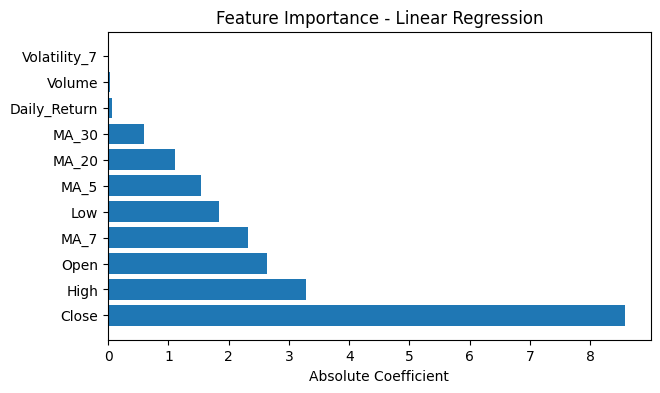

In [88]:
plt.figure(figsize=(7,4))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Absolute_Coefficient']
)

plt.xlabel('Absolute Coefficient')
plt.title('Feature Importance - Linear Regression')

plt.show()